# Customer Churn Prediction using ANN

In [ ]:
import tensorflow as tf

Imports TensorFlow for building and training machine learning models.

In [ ]:
import numpy as np
import pandas as pd

 Imports NumPy for handling numerical computations and arrays.
 Imports Pandas for data manipulation and analysis using dataframes.

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Churn_Modelling.csv to Churn_Modelling.csv


In [ ]:
import pandas as pd

data = pd.read_csv("Churn_Modelling.csv")
data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


Loads the CSV file into a Pandas DataFrame called data, which stores the churn dataset.Displays the first 5 rows of the dataset to preview its content

In [ ]:
data.size,data.shape

(140000, (10000, 14))

Returns the total number of elements (cells) in the DataFrame (rows × columns).
Returns the shape of the DataFrame as a tuple, where the first element is the number of rows and the second element is the number of columns.








In [ ]:
df = data

Creates a copy of the data DataFrame and assigns it to the variable df, allowing you to work with df while keeping the original data intact.

In [ ]:
df.drop(columns = ['Surname','RowNumber','CustomerId'])

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


Removes the Surname, RowNumber, and CustomerId columns from the df DataFrame.


In [ ]:
import sklearn

Imports the scikit-learn library for accessing machine learning algorithms and data preprocessing tools.

In [ ]:
from sklearn.preprocessing import LabelBinarizer
le = LabelBinarizer()
col = ['Geography','Gender']
for col in df.select_dtypes(include=[object]).columns:
    df[col] = le.fit_transform(df[col])

 Imports LabelBinarizer, a tool used to convert categorical variables into binary (0/1) format.
 le = LabelBinarizer()
 Initializes the `LabelBinarizer` object to later transform categorical columns.
col = ['Geography', 'Gender']
 Defines a list of column names that contain categorical data (for label binarization).
 for col in df.select_dtypes(include=[object]).columns:  
   Iterates through all columns in `df` that have the data type `object` (categorical variables).
 df[col] = le.fit_transform(df[col)
   Transforms the categorical values in each selected column into binary (0 or 1) and assigns them back to the DataFrame.

In [ ]:
df[:5]

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,0,619,1,0,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,0,608,0,0,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,0,502,1,0,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,0,699,1,0,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,0,850,0,0,43,2,125510.82,1,1,1,79084.10,0


Displays the first five rows of the dataframe.

In [ ]:
df.drop(columns = ["CustomerId","Surname","RowNumber"],inplace=True)

Deletes columns customerid, surname, rownumber

In [ ]:
df[:5]

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,1,0,42,2,0.00,1,1,1,101348.88,1
1,608,0,0,41,1,83807.86,1,0,1,112542.58,0
2,502,1,0,42,8,159660.80,3,1,0,113931.57,1
3,699,1,0,39,1,0.00,2,0,0,93826.63,0
4,850,0,0,43,2,125510.82,1,1,1,79084.10,0


displays rows from index 0 to 5

In [31]:
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split

Imports the Keras API from TensorFlow, which is used for building and training neural networks.
Imports various layers from Keras, which are used to construct the architecture of neural networks.
 Imports the train_test_split function from scikit-learn to split the dataset into training and testing subsets.

In [ ]:
X=df.drop(columns=['Exited'])
y=df['Exited']

 Creates a new DataFrame `X` that contains all columns from `df` except for the `Exited` column, which represents the features used for prediction.
 Assigns the `Exited` column from `df` to the variable `y`, which serves as the target variable for the prediction task.

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

Splits the feature set X and target variable y into training and testing subsets, using 20% of the data for testing and a fixed random seed for reproducibility.

In [ ]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.fit_transform(X_test)

The code imports `StandardScaler` from scikit-learn to standardize features by removing the mean and scaling to unit variance. It initializes the scaler and then applies it to the training data `X_train` using `fit_transform()`, which correctly scales the features. However, it incorrectly applies `fit_transform()` to the test data `X_test`, which should instead use `transform()` to avoid data leakage by fitting the scaler to the test set.

In [ ]:
import tensorflow

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout

 Imports the TensorFlow library as a whole, providing access to its extensive functionality for building and training machine learning models, including neural networks, optimizers, and various utilities.Imports the Sequential model type from Keras, which allows you to build a neural network layer by layer in a linear stack.

from tensorflow.keras.layers import Dense, Dropout:
Imports the Dense and Dropout layers from Keras, where Dense is used for fully connected layers in the neural network and Dropout is used to prevent overfitting by randomly setting a fraction of input units to zero during training.

In [ ]:
model =Sequential([
    Dense(64,activation='relu'),
    Dense(64,activation='relu'),
    Dense(64,activation='relu'),
    tf.keras.layers.Flatten(),
    Dense(1,activation='sigmoid')
])


Creates a sequential neural network model consisting of three dense layers with ReLU activation, a flattening layer, and an output layer with a sigmoid activation function for binary classification.

In [ ]:
model.compile(optimizer="adam",loss="MeanSquaredError",metrics=['accuracy'])

Configures the model for training by setting the Adam optimizer, specifying the loss function as mean squared error, and tracking accuracy as a performance metric during training and evaluation.

In [ ]:
hist = model.fit(X_train,y_train,epochs=100)

Epoch 1/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8213 - loss: 0.1360
Epoch 2/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8520 - loss: 0.1102
Epoch 3/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8575 - loss: 0.1070
Epoch 4/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8562 - loss: 0.1048
Epoch 5/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8616 - loss: 0.1038
Epoch 6/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8626 - loss: 0.1023
Epoch 7/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8622 - loss: 0.1015
Epoch 8/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8645 - loss: 0.1006
Epoch 9/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8651 - loss: 0.0997
Epoch 10/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8649 - loss: 0.0989
Epoch 11/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8677 - loss: 0.0983
Epoch 12/100
250/250 ━━━━━━━━━━━━━━━━━━━━

Trains the neural network model on the training data X_train and target y_train for 100 epochs, with the training process and performance metrics stored in the hist variable.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

Imports the pyplot module from the Matplotlib library, allowing for the creation of static, interactive, and animated visualizations in Python.
Imports the Seaborn library, which is built on Matplotlib, to provide a high-level interface for drawing attractive and informative statistical graphics.

Text(0.5, 1.0, 'Loss and Accuracy Curves')

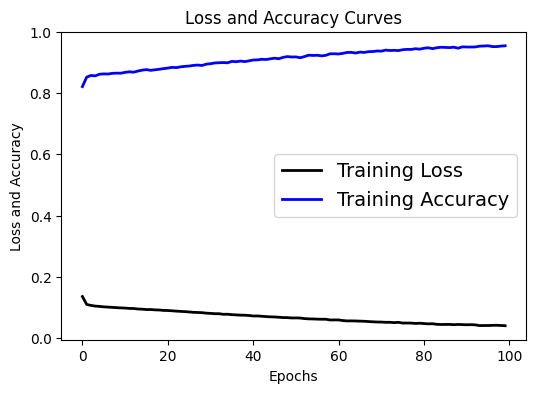

In [ ]:
plt.figure(figsize=[6,4])
plt.plot(hist.history['loss'], 'black', linewidth=2.0)
plt.plot(hist.history['accuracy'], 'blue', linewidth=2.0)
plt.legend(['Training Loss','Training Accuracy'], fontsize=14)
plt.xlabel('Epochs', fontsize=10)
plt.ylabel('Loss and Accuracy', fontsize=10)
plt.title('Loss and Accuracy Curves', fontsize=12)

The code creates a new Matplotlib figure sized 6 by 4 inches and plots two curves: the training loss in black and the training accuracy in blue, both with a line width of 2.0. It includes a legend to distinguish between the two curves, labels the x-axis as "Epochs" and the y-axis as "Loss and Accuracy," and sets the title of the plot to "Loss and Accuracy Curves," providing a visual representation of the model's performance over the training epochs.

In [ ]:
model.layers[0].get_weights()

[array([[-0.27345183,  0.444251  ,  0.11378691,  0.37754777,  0.08425599,
          0.20354158,  0.13527669, -0.3054915 , -0.24634704,  0.15087245,
          0.31047046, -0.15537146, -0.05704277, -0.05379746, -0.45826516,
          0.1825237 ,  0.23912156, -0.566813  , -0.427572  , -0.07179201,
         -0.177929  , -0.43271935,  0.28214648, -0.42703417, -0.03219787,
          0.27981868, -0.4815952 ,  0.12496925, -0.1990082 ,  0.23908728,
          0.536964  ,  0.00552658, -0.28188404, -0.27653465,  0.11024596,
         -0.0539876 , -0.06287353,  0.50921845, -0.26802143,  0.21172245,
          0.25495377,  0.3072715 , -0.18324536, -0.08607906,  0.51569694,
         -0.3905306 ,  0.29147747,  0.40956834, -0.3450333 , -0.10639916,
          0.3994043 , -0.13297601,  0.21789823, -0.4320664 , -0.01399712,
         -0.37405372, -0.00493809,  0.09732028,  0.12483259, -0.20778418,
          0.25768155,  0.23633005,  0.49108854, -0.14475009],
        [-0.3368775 , -0.17503726,  0.17573874, -0

Retrieves the weights and biases of the first layer in the neural network model.

In [ ]:
y_log = model.predict(X_test)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [ ]:
y_pred = np.where(y_log > 0.5, 1, 0)

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.823

 Imports the `accuracy_score` function from scikit-learn, which is used to calculate the accuracy of a classification model.
 Computes the accuracy of the model by comparing the true labels `y_test` with the predicted labels `y_pred`, returning the proportion of correct predictions.